# 04 — Models

**Inputs:** `data/analysis_panel_wages.csv`
**Function:** fit linear and gradient-boosted models for the initial denial rate and for any-denial, test temporal robustness, and measure what the DOL wage block adds
**Outputs:** `output/figures/06`–`09`, `13`–`14`; `output/tables/model_comparison*.csv`, `*_importance*.csv`

Three questions, in order:

1. **How predictable is a denial at all**, from employer characteristics? (§2–3)
2. **Does that predictability survive forward validation?** (§4) — it does not, and
   this is the paper's headline.
3. **Do wages add signal** once size, history, sector and year are controlled for? (§6)

In [1]:
import sys
from pathlib import Path

# Locate the repository root by walking up until code/src is found, then put the
# code directory on the path. No absolute paths, so this runs from any checkout.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "code" / "src").is_dir())
sys.path.insert(0, str(_root / "code"))

import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

from src import (DATA, TABLES, MODEL_YEARS, finish, save,
                 C1, C2, SEQ, INK, INK2, MUTED)

warnings.filterwarnings("ignore")
SEED = 45

## Functions and feature definitions

**Dependent variable:** `denial_rate`, the share of an employer-year's *initial*
petitions that were denied. The binary `any_denial` is modelled alongside it because the
rate has enormous mass at exactly 0 and 1.

**Independent variables:** petition volume, renewal intensity, prior-year sponsorship
history, sponsorship tenure, industry sector, state, and fiscal year standing in for the
observed calendar-year context. Every history feature is strictly backward-looking (see `02_merge`), so
none of them can leak the current year's outcome.

In [2]:
NUMERIC = ["log_initial", "continuing_share", "log_prev_initial",
           "prev_denial_rate", "years_active", "is_repeat_sponsor"]
CATEG = ["sector", "state_grp", "fy_cat"]

WAGE_NUM = ["wage_ratio_med", "log_wage_annual", "share_low_level",
            "share_agent", "share_dependent", "log_lca_filings"]
WAGE_CAT = ["soc2_modal"]

PRETTY = {
    "log_initial": "log(1 + initial petitions)",
    "continuing_share": "Continuing (renewal) share",
    "log_prev_initial": "log(1 + prior-yr initial petitions)",
    "prev_denial_rate": "Prior-year denial rate",
    "years_active": "Years active as sponsor",
    "is_repeat_sponsor": "Sponsored in prior year",
    "wage_ratio_med": "Offered / prevailing wage",
    "log_wage_annual": "log(median offered wage)",
    "share_low_level": "Share at PW level I or II",
    "share_agent": "Share filed via agent or attorney",
    "share_dependent": "Share at H-1B dependent employer",
    "log_lca_filings": "log(1 + LCA filings)",
}

SHAP_NAMES = dict(PRETTY)
SHAP_NAMES.update({"fy_cat": "Fiscal year", "sector": "Industry sector",
                   "state_grp": "State", "soc2_modal": "Modal SOC group"})


def design_matrices(frame, numeric, categorical):
    """Build the linear (one-hot) and tree (native categorical) designs together."""
    X_lin = pd.get_dummies(frame[numeric + categorical],
                           columns=categorical, drop_first=True).astype(float)
    X_gbm = frame[numeric + categorical].copy()
    for c in categorical:
        X_gbm[c] = X_gbm[c].astype("category")
    return X_lin, X_gbm


def lgb_regressor(**kw):
    params = dict(n_estimators=700, learning_rate=0.05, num_leaves=48,
                  min_child_samples=40, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, random_state=SEED, verbose=-1)
    params.update(kw)
    return lgb.LGBMRegressor(**params)


def lgb_classifier(**kw):
    params = dict(n_estimators=700, learning_rate=0.05, num_leaves=48,
                  min_child_samples=40, random_state=SEED, verbose=-1)
    params.update(kw)
    return lgb.LGBMClassifier(**params)


def forest_plot(res, labels, title, subtitle, xlab, name):
    """Coefficient plot: point estimate, 95% CI, grey when p >= 0.05."""
    fig, ax = plt.subplots(figsize=(7.8, 0.34 * len(res) + 1.8))
    ypos = np.arange(len(res))[::-1]
    sig = res.p < 0.05
    ax.hlines(ypos, res.lo, res.hi, color=np.where(sig, C1, MUTED), lw=2)
    ax.scatter(res.coef, ypos, s=34, color=np.where(sig, C1, MUTED), zorder=3)
    ax.axvline(0, color=INK2, lw=1, ls="--")
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    finish(ax, title, subtitle, xlab, None, grid="x")
    save(name)

## 1. Set up the modelling sample

FY2023 is excluded: it is a partial-year extract, and the DOL wage data stops at FY2022.

In [3]:
panel = pd.read_csv(DATA / "analysis_panel_wages.csv", low_memory=False)
fit_df = panel[panel.fy.isin(MODEL_YEARS)].copy()
fit_df["fy_cat"] = fit_df.fy.astype(str)

y = fit_df.denial_rate.values
y_bin = fit_df.any_denial.values
X_lin, X_gbm = design_matrices(fit_df, NUMERIC, CATEG)

idx = np.arange(len(fit_df))
tr, te = train_test_split(idx, test_size=0.30, random_state=SEED,
                          stratify=fit_df.fy)
print(f"modelling rows: {len(fit_df):,}")
print(f"train n={len(tr):,}   test n={len(te):,}   (stratified by fiscal year)")
print(f"linear design: {X_lin.shape[1]} columns after one-hot encoding")
print(f"outcome mean  train {y[tr].mean():.4f}   test {y[te].mean():.4f}")

modelling rows: 172,993
train n=121,095   test n=51,898   (stratified by fiscal year)
linear design: 43 columns after one-hot encoding
outcome mean  train 0.1310   test 0.1315


## 2. Regression on the denial rate

In [4]:
ols = sm.OLS(y[tr], sm.add_constant(X_lin.iloc[tr])).fit(cov_type="HC1")
ols_pred = ols.predict(sm.add_constant(X_lin.iloc[te], has_constant="add"))
r2_ols = r2_score(y[te], ols_pred)

gbm = lgb_regressor()
gbm.fit(X_gbm.iloc[tr], y[tr], eval_set=[(X_gbm.iloc[te], y[te])],
        callbacks=[lgb.early_stopping(50, verbose=False)])
r2_gbm = r2_score(y[te], gbm.predict(X_gbm.iloc[te]))

print(f"In-sample OLS R2:  {ols.rsquared:.4f}")
print(f"Held-out R2   OLS: {r2_ols:.4f}   LightGBM: {r2_gbm:.4f}")

In-sample OLS R2:  0.0982
Held-out R2   OLS: 0.1047   LightGBM: 0.1471


Both numbers are low in absolute terms. That is the substantive finding, not a failure:
employer characteristics explain a modest share of the variance in denial outcomes, which
is what a street-level-discretion account would predict. The gap between OLS and LightGBM
says some of the remaining structure is non-linear.

## 3. Classification: was there *any* denial?

Because the rate is so lumpy, the binary version is the better-behaved framing, and the
AUCs are correspondingly much more informative.

In [5]:
logit = LogisticRegression(max_iter=3000, C=1.0)
logit.fit(X_lin.iloc[tr], y_bin[tr])
auc_logit = roc_auc_score(y_bin[te], logit.predict_proba(X_lin.iloc[te])[:, 1])

clf = lgb_classifier()
clf.fit(X_gbm.iloc[tr], y_bin[tr], eval_set=[(X_gbm.iloc[te], y_bin[te])],
        callbacks=[lgb.early_stopping(50, verbose=False)])
auc_gbm = roc_auc_score(y_bin[te], clf.predict_proba(X_gbm.iloc[te])[:, 1])

print(f"AUC (any denial)   Logistic: {auc_logit:.4f}   LightGBM: {auc_gbm:.4f}")

comp = pd.DataFrame({
    "Model": ["OLS (linear)", "LightGBM (gradient boosting)",
              "Logistic (linear)", "LightGBM classifier"],
    "Target": ["Initial denial rate"] * 2 + ["Any initial denial (0/1)"] * 2,
    "Metric": ["R2", "R2", "ROC AUC", "ROC AUC"],
    "Held-out score": [round(r2_ols, 4), round(r2_gbm, 4),
                       round(auc_logit, 4), round(auc_gbm, 4)],
})
comp.to_csv(TABLES / "model_comparison.csv", index=False)
print()
print(comp.to_string(index=False))

AUC (any denial)   Logistic: 0.7899   LightGBM: 0.8023

                       Model                   Target  Metric  Held-out score
                OLS (linear)      Initial denial rate      R2          0.1047
LightGBM (gradient boosting)      Initial denial rate      R2          0.1471
           Logistic (linear) Any initial denial (0/1) ROC AUC          0.7899
         LightGBM classifier Any initial denial (0/1) ROC AUC          0.8023


## 4. The temporal test — the headline result

The random split above lets the model see FY2022 rows during training, so the fiscal-year
dummy does most of the work. The forward test asks whether anything learned in earlier
years transfers to a held-out year: train on FY2017–FY2021, predict FY2022, with the
year feature **dropped**, since it cannot be extrapolated to an unseen year.

In [6]:
tr_t = np.where(fit_df.fy <= 2021)[0]
te_t = np.where(fit_df.fy == 2022)[0]
Xl_t = X_lin[[c for c in X_lin.columns if not c.startswith("fy_cat_")]]
Xg_t = X_gbm.drop(columns=["fy_cat"])

ols_t = sm.OLS(y[tr_t], sm.add_constant(Xl_t.iloc[tr_t])).fit(cov_type="HC1")
r2_ols_t = r2_score(y[te_t], ols_t.predict(
    sm.add_constant(Xl_t.iloc[te_t], has_constant="add")))

gbm_t = lgb_regressor(n_estimators=400, subsample=1.0, subsample_freq=0,
                      colsample_bytree=1.0)
gbm_t.fit(Xg_t.iloc[tr_t], y[tr_t])
r2_gbm_t = r2_score(y[te_t], gbm_t.predict(Xg_t.iloc[te_t]))

print("Temporal split (train <=FY2021, test FY2022, no year feature)")
print(f"  R2   OLS: {r2_ols_t:.4f}   LightGBM: {r2_gbm_t:.4f}")
print(f"  Mean denial rate   train: {y[tr_t].mean():.4f}   test: {y[te_t].mean():.4f}")

Temporal split (train <=FY2021, test FY2022, no year feature)
  R2   OLS: -0.6182   LightGBM: -0.7085
  Mean denial rate   train: 0.1521   test: 0.0318


**Both R² values are negative** — their squared prediction error exceeds the benchmark
that assigns every FY2022 employer-year the FY2022 sample mean. The more flexible model
does slightly worse, which is consistent with training-period relationships that are poorly
calibrated to FY2022, but the comparison alone does not identify why the level changed.

The figure below shows why. Predictions remain in a narrow band near the training-period
average and fail to follow the observed decline.

findfont: Failed to find font weight 600, now using 700.


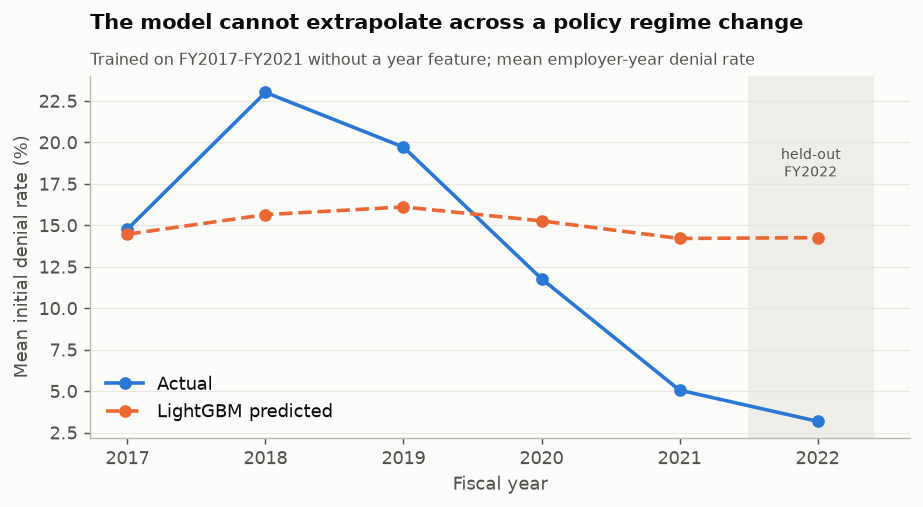

      actual   pred
fy                 
2017   14.76  14.46
2018   23.01  15.64
2019   19.71  16.10
2020   11.77  15.26
2021    5.05  14.20
2022    3.18  14.25


In [7]:
pred_all_t = gbm_t.predict(Xg_t)
tmp = pd.DataFrame({"fy": fit_df.fy.values, "actual": y, "pred": pred_all_t})
byyr = tmp.groupby("fy")[["actual", "pred"]].mean() * 100

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(byyr.index, byyr.actual, color=C1, marker="o", markersize=6, label="Actual")
ax.plot(byyr.index, byyr.pred, color=C2, marker="o", markersize=6, ls="--",
        label="LightGBM predicted")
ax.axvspan(2021.5, 2022.4, color="#eeede8", zorder=0)
ax.text(2021.95, byyr.values.max() * 0.78, "held-out\nFY2022", ha="center",
        fontsize=8, color=INK2)
ax.legend(loc="lower left")
finish(ax, "The model misses the sharp decline in the held-out year",
       "Trained on FY2017-FY2021 without a year feature; mean employer-year denial rate",
       "Fiscal year", "Mean initial denial rate (%)")
save("09_temporal_failure")

byyr.round(2).to_csv(TABLES / "temporal_actual_vs_predicted.csv")
print(byyr.round(2).to_string())

## 5. What drives the predictions

Two views of the same model: OLS coefficients with robust confidence intervals, and SHAP
values from the gradient-boosted model.

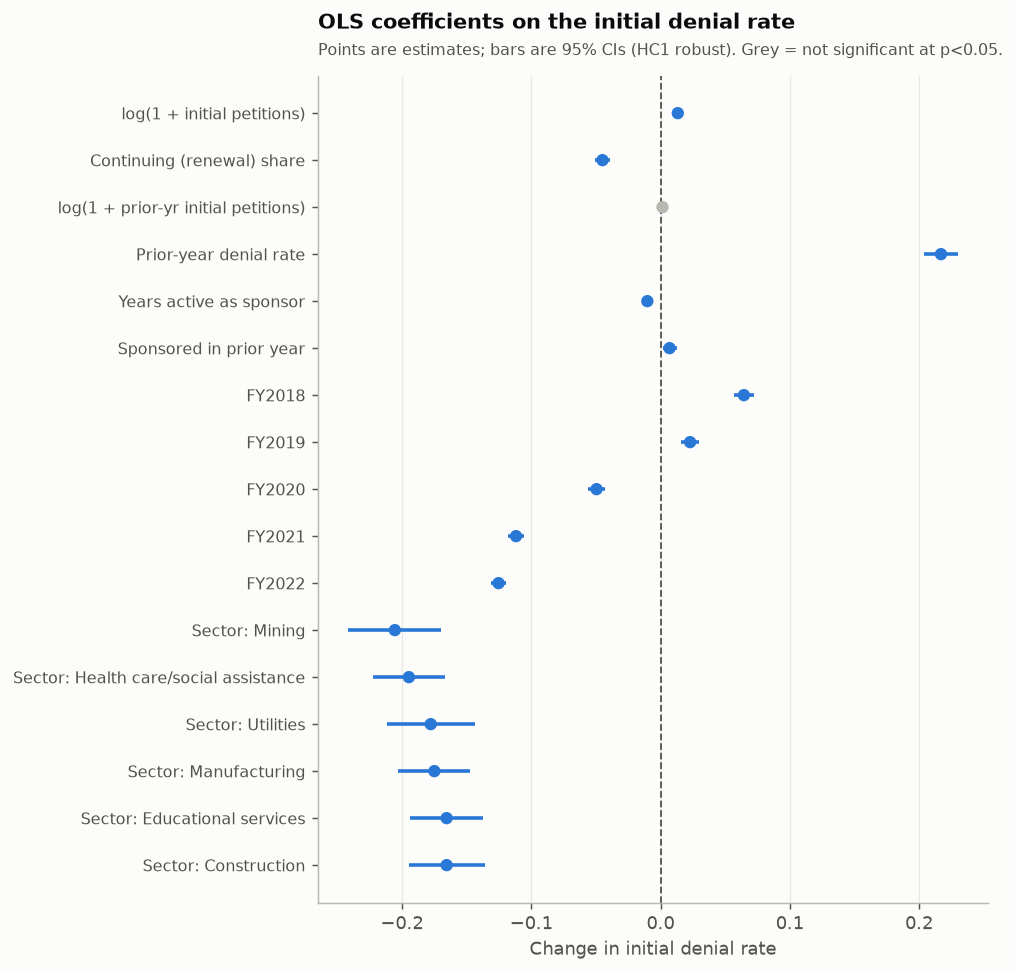

Selected coefficients:
  log(1 + initial petitions)              0.0134   p=2.79e-25
  Continuing (renewal) share             -0.0449   p=8.2e-53
  log(1 + prior-yr initial petitions)     0.0015   p=0.215
  Prior-year denial rate                  0.2169   p=1.12e-241
  Years active as sponsor                -0.0102   p=9.94e-71
  Sponsored in prior year                 0.0070   p=0.0117


In [8]:
res = pd.DataFrame({"coef": ols.params, "lo": ols.conf_int()[0],
                    "hi": ols.conf_int()[1], "p": ols.pvalues}).drop("const")

sector_rows = res[res.index.str.startswith("sector_")]
top_sectors = sector_rows.reindex(
    sector_rows.coef.abs().sort_values(ascending=False).index[:6])
show = pd.concat([res.loc[[c for c in res.index if c in PRETTY]],
                  res[res.index.str.startswith("fy_cat_")],
                  top_sectors])
labels = [PRETTY.get(i, i.replace("fy_cat_", "FY").replace("sector_", "Sector: "))
          for i in show.index]

forest_plot(show, labels,
            "OLS coefficients on the initial denial rate",
            "Points are estimates; bars are 95% CIs (HC1 robust). "
            "Grey = not significant at p<0.05.",
            "Change in initial denial rate", "06_forest_plot_ols")

print("Selected coefficients:")
for k in NUMERIC:
    print(f"  {PRETTY[k]:38s} {ols.params[k]: .4f}   p={ols.pvalues[k]:.3g}")

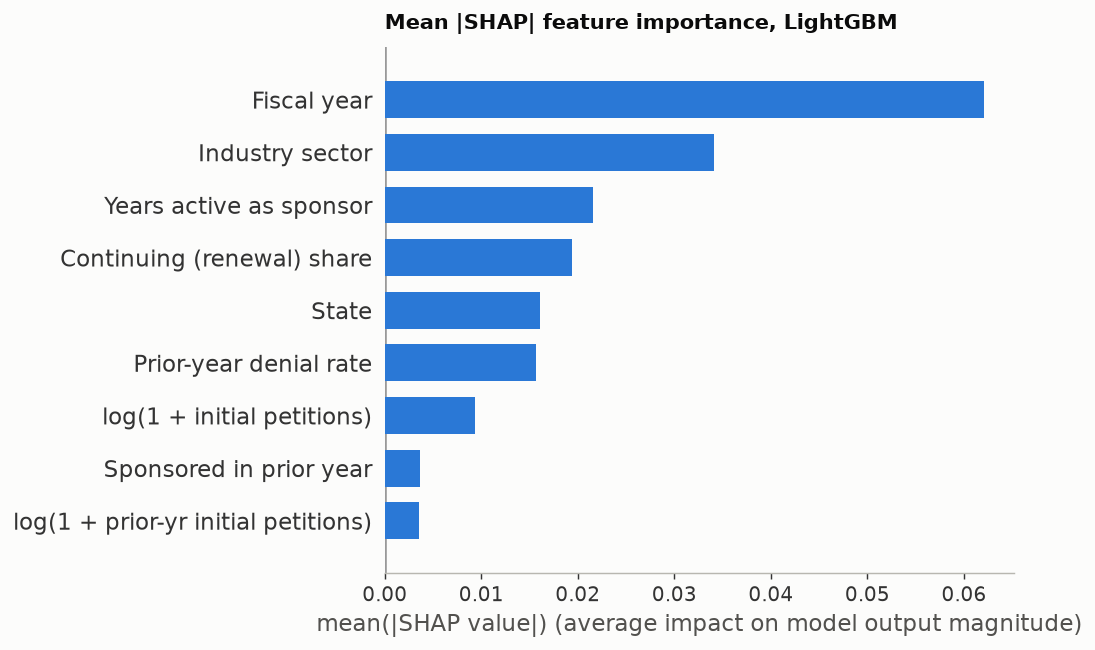

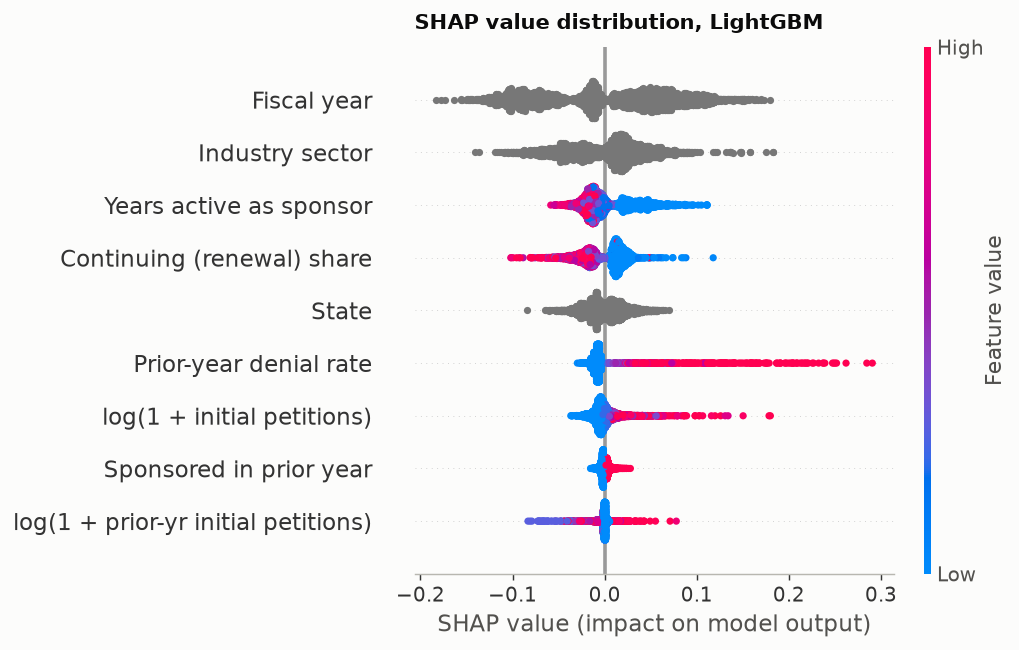

In [9]:
explainer = shap.TreeExplainer(gbm)
samp = X_gbm.iloc[te].sample(4000, random_state=SEED)
sv = explainer.shap_values(samp)
samp = samp.rename(columns=SHAP_NAMES)

plt.figure(figsize=(7.6, 4.6))
shap.summary_plot(sv, samp, plot_type="bar", show=False, color=SEQ, max_display=12)
plt.title("Mean |SHAP| feature importance, LightGBM", loc="left",
          fontsize=11.5, color=INK)
save("07_shap_bar")

plt.figure(figsize=(7.6, 5.2))
shap.summary_plot(sv, samp, show=False, max_display=12)
plt.title("SHAP value distribution, LightGBM", loc="left", fontsize=11.5, color=INK)
save("08_shap_beeswarm")

In [10]:
# Standardised betas make the linear and tree importances comparable.
std_beta = (ols.params.drop("const") * X_lin.std()) / y.std()
lin_imp = std_beta.abs().sort_values(ascending=False).head(10)
gbm_imp = pd.Series(np.abs(sv).mean(0), index=samp.columns).sort_values(ascending=False)

lin_imp.to_csv(TABLES / "linear_importance.csv")
gbm_imp.to_csv(TABLES / "shap_importance.csv")

print("Top |standardised OLS beta|:")
print(lin_imp.round(4).to_string())
print("\nMean |SHAP| ranking:")
print(gbm_imp.round(5).to_string())

Top |standardised OLS beta|:
sector_Manufacturing                        0.1795
sector_Health care/social assistance        0.1778
sector_Professional/scientific/technical    0.1677
fy_cat_2022                                 0.1546
fy_cat_2021                                 0.1321
sector_Educational services                 0.1311
prev_denial_rate                            0.1214
sector_Finance/insurance                    0.1166
sector_Information                          0.1083
fy_cat_2018                                 0.0785

Mean |SHAP| ranking:
Fiscal year                            0.06208
Industry sector                        0.03415
Years active as sponsor                0.02154
Continuing (renewal) share             0.01945
State                                  0.01607
Prior-year denial rate                 0.01565
log(1 + initial petitions)             0.00930
Sponsored in prior year                0.00364
log(1 + prior-yr initial petitions)    0.00352


## 6. Does the wage block add anything?

Both models here are fitted on the **same matched subsample** — the employer-years that
carry DOL wage data. The baseline is refitted on that subsample rather than reused from
§2, so the comparison isolates the wage features rather than a change of sample. See
`02_merge` §4 for why this matters: match rate rises with employer size, so the matched
subsample is not a random draw.

In [11]:
matched = panel.lca_filings.notna() & panel.fy.isin(MODEL_YEARS)
fitw = panel[matched].copy()
fitw["fy_cat"] = fitw.fy.astype(str)
fitw["log_wage_annual"] = np.log(fitw.wage_annual_med)
fitw["log_lca_filings"] = np.log1p(fitw.lca_filings)
fitw["soc2_modal"] = fitw.soc2_modal.fillna(-1).astype(float).astype(int).astype(str)
for c in WAGE_NUM:
    fitw[c] = fitw[c].fillna(fitw[c].median())

yw = fitw.denial_rate.values
ywb = fitw.any_denial.values
trw, tew = train_test_split(np.arange(len(fitw)), test_size=0.30,
                            random_state=SEED, stratify=fitw.fy)
print(f"matched subsample: {len(fitw):,} rows "
      f"({len(fitw) / len(fit_df):.1%} of the modelling window)")
print(f"train n={len(trw):,}   test n={len(tew):,}")

matched subsample: 125,678 rows (72.6% of the modelling window)
train n=87,974   test n=37,704


In [12]:
def fit_pair(numeric, categorical, label):
    """Fit all four models on the matched subsample and report held-out scores."""
    X_lin, X_gbm = design_matrices(fitw, numeric, categorical)

    o = sm.OLS(yw[trw], sm.add_constant(X_lin.iloc[trw])).fit(cov_type="HC1")
    r2o = r2_score(yw[tew], o.predict(
        sm.add_constant(X_lin.iloc[tew], has_constant="add")))

    g = lgb_regressor()
    g.fit(X_gbm.iloc[trw], yw[trw], eval_set=[(X_gbm.iloc[tew], yw[tew])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    r2g = r2_score(yw[tew], g.predict(X_gbm.iloc[tew]))

    lg = LogisticRegression(max_iter=3000)
    lg.fit(X_lin.iloc[trw], ywb[trw])
    aucl = roc_auc_score(ywb[tew], lg.predict_proba(X_lin.iloc[tew])[:, 1])

    cf = lgb_classifier()
    cf.fit(X_gbm.iloc[trw], ywb[trw], eval_set=[(X_gbm.iloc[tew], ywb[tew])],
           callbacks=[lgb.early_stopping(50, verbose=False)])
    aucg = roc_auc_score(ywb[tew], cf.predict_proba(X_gbm.iloc[tew])[:, 1])

    print(f"{label:22s} OLS R2 {r2o:.4f}   LGBM R2 {r2g:.4f}   "
          f"Logit AUC {aucl:.4f}   LGBM AUC {aucg:.4f}")
    return dict(label=label, r2_ols=r2o, r2_gbm=r2g, auc_logit=aucl,
                auc_gbm=aucg, ols=o, gbm=g, X_lin=X_lin, X_gbm=X_gbm)


base = fit_pair(NUMERIC, CATEG, "Baseline (no wages)")
full = fit_pair(NUMERIC + WAGE_NUM, CATEG + WAGE_CAT, "With wage features")

comp2 = pd.DataFrame(
    [{"Model": "OLS", "Features": b["label"], "R2": round(b["r2_ols"], 4),
      "AUC": round(b["auc_logit"], 4)} for b in (base, full)] +
    [{"Model": "LightGBM", "Features": b["label"], "R2": round(b["r2_gbm"], 4),
      "AUC": round(b["auc_gbm"], 4)} for b in (base, full)])
comp2.to_csv(TABLES / "model_comparison_wages.csv", index=False)
print()
print(comp2.to_string(index=False))

Baseline (no wages)    OLS R2 0.1150   LGBM R2 0.1596   Logit AUC 0.8236   LGBM AUC 0.8329


With wage features     OLS R2 0.1426   LGBM R2 0.2046   Logit AUC 0.8393   LGBM AUC 0.8498

   Model            Features     R2    AUC
     OLS Baseline (no wages) 0.1150 0.8236
     OLS  With wage features 0.1426 0.8393
LightGBM Baseline (no wages) 0.1596 0.8329
LightGBM  With wage features 0.2046 0.8498


The wage block adds real signal on both targets and for both model families — the gain is
not an artifact of tree flexibility.

### Wage coefficients

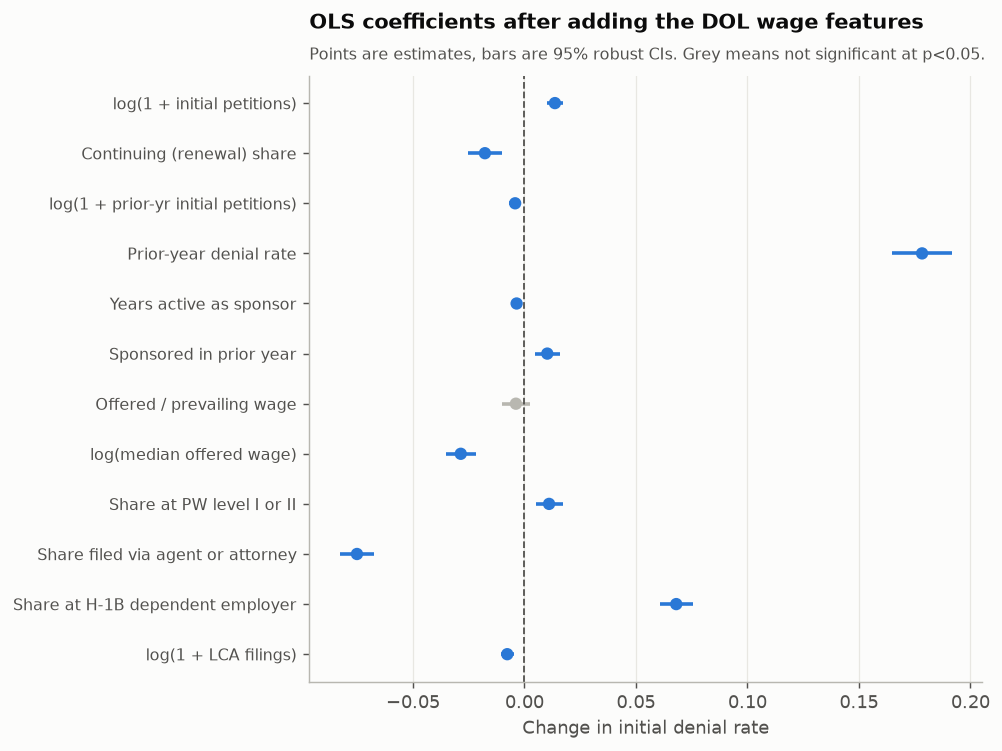

Wage-feature coefficients:
  Offered / prevailing wage            -0.0038   p=0.239
  log(median offered wage)             -0.0286   p=3.68e-17
  Share at PW level I or II             0.0110   p=0.000338
  Share filed via agent or attorney    -0.0751   p=3.19e-82
  Share at H-1B dependent employer      0.0681   p=3.21e-74
  log(1 + LCA filings)                 -0.0077   p=8.51e-08


In [13]:
ow = full["ols"]
res2 = pd.DataFrame({"coef": ow.params, "lo": ow.conf_int()[0],
                     "hi": ow.conf_int()[1], "p": ow.pvalues}).drop("const")
order = [c for c in PRETTY if c in res2.index]
show2 = res2.loc[order]

forest_plot(show2, [PRETTY[i] for i in show2.index],
            "OLS coefficients after adding the DOL wage features",
            "Points are estimates, bars are 95% robust CIs. "
            "Grey means not significant at p<0.05.",
            "Change in initial denial rate", "13_forest_plot_wages")

print("Wage-feature coefficients:")
for k in WAGE_NUM:
    print(f"  {PRETTY[k]:36s} {ow.params[k]: .4f}   p={ow.pvalues[k]:.3g}")

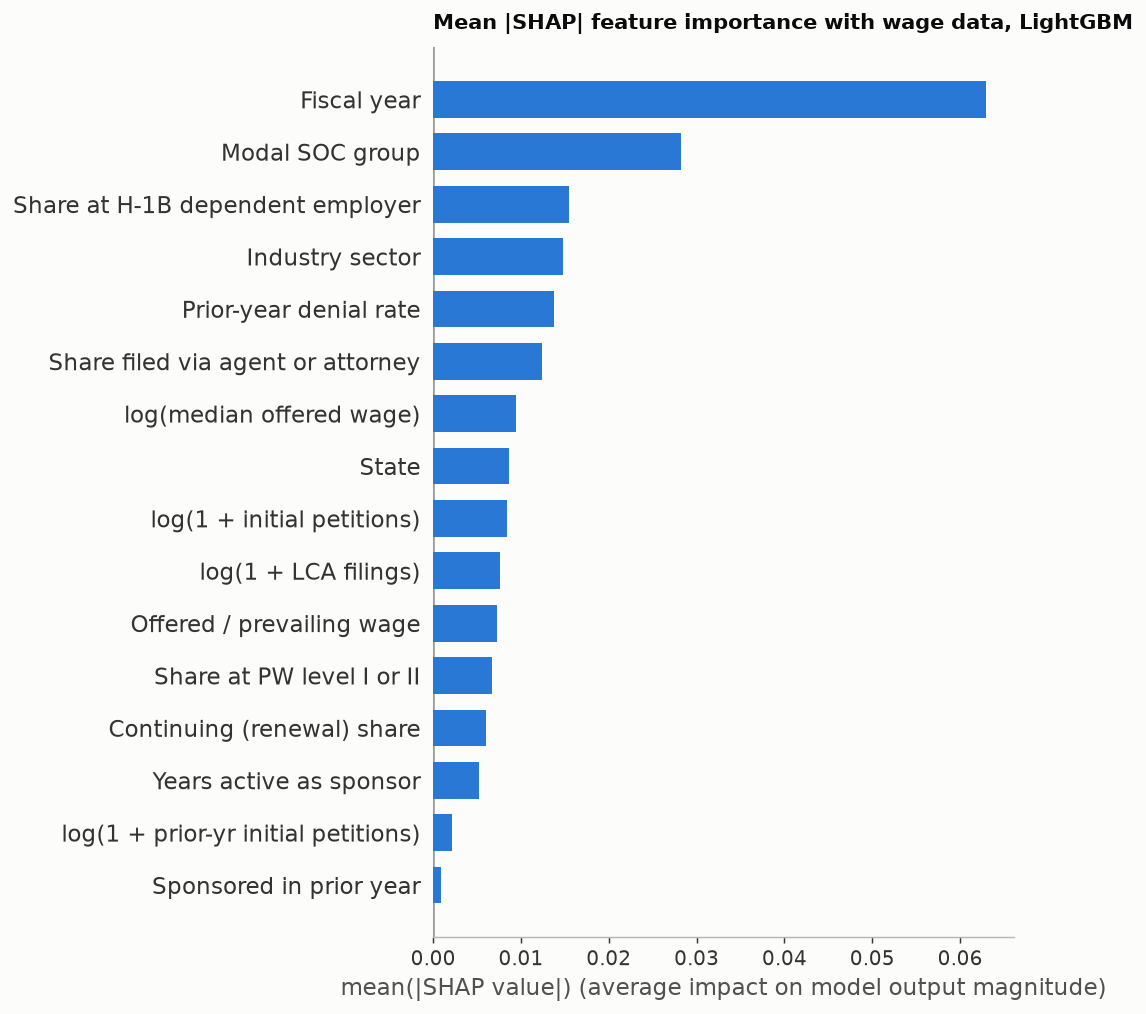

Fiscal year                            0.06298
Modal SOC group                        0.02817
Share at H-1B dependent employer       0.01548
Industry sector                        0.01473
Prior-year denial rate                 0.01372
Share filed via agent or attorney      0.01238
log(median offered wage)               0.00948
State                                  0.00863
log(1 + initial petitions)             0.00845
log(1 + LCA filings)                   0.00766
Offered / prevailing wage              0.00726
Share at PW level I or II              0.00667
Continuing (renewal) share             0.00601
Years active as sponsor                0.00521
log(1 + prior-yr initial petitions)    0.00211
Sponsored in prior year                0.00088


In [14]:
explainer2 = shap.TreeExplainer(full["gbm"])
samp2 = full["X_gbm"].iloc[tew].sample(4000, random_state=SEED)
sv2 = explainer2.shap_values(samp2)
samp2 = samp2.rename(columns=SHAP_NAMES)

plt.figure(figsize=(7.6, 5.2))
shap.summary_plot(sv2, samp2, plot_type="bar", show=False, color=SEQ, max_display=16)
plt.title("Mean |SHAP| feature importance with wage data, LightGBM", loc="left",
          fontsize=11.5, color=INK)
save("14_shap_bar_wages")

gbm_imp2 = pd.Series(np.abs(sv2).mean(0), index=samp2.columns).sort_values(ascending=False)
gbm_imp2.to_csv(TABLES / "shap_importance_wages.csv")
print(gbm_imp2.round(5).to_string())

## Summary

| Question | Answer |
|---|---|
| Is a denial predictable from employer characteristics? | Modestly. AUC ≈ 0.80 for any-denial; R² ≈ 0.15 for the rate. |
| Does that predictability survive forward validation? | **No.** Trained on FY2017–FY2021 and tested on FY2022, both models post negative R². |
| Do wages add signal? | Yes. LightGBM R² 0.160 → 0.205 and AUC 0.833 → 0.850 on an identical subsample. |

The headline is the second row. Features that modestly predict relative risk when train
and test contain the same years do not recover the sharp FY2022 decline. This is consistent
with administrative context mattering, but it does not identify a specific policy cause.